In [1]:
import os

# Set working directory to this notebook's folder
os.chdir(os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd())
print("Working directory:", os.getcwd())

import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No CUDA detected. Install PyTorch CUDA:")
    print("  pip install torch --index-url https://download.pytorch.org/whl/cu121")

Working directory: c:\Users\Yunus Kounkourou\Documents\GitHub\CARTIQ-ML-PROJECT\ml\notebooks
CUDA available: True
GPU: NVIDIA GeForce RTX 2060
VRAM: 6.4 GB


# Phase 5 — GRU Sequential Recommender

**Lead: Abir** | Steps 5.1 – 5.5

| Step | Description |
|---|---|
| 5.1 | Define GRU model: Embedding → GRU(hidden=128, layers=2) → Linear → Sigmoid |
| 5.2 | Build sequence dataset: (input_sequence, next_basket_label) pairs |
| 5.3 | Train: Adam (lr=5e-4), gradient clipping (max_norm=1.0), up to 15 epochs |
| 5.4 | Evaluate: Precision@10, Recall@10, F1@10 |
| 5.5 | Full four-model comparison table |

**Reference:** Hidasi et al., 2016. Session-based Recommendations with RNNs. ICLR.

**Prerequisite:** Run `02_feature_engineering.ipynb` and `03_baseline_gbdt.ipynb` first.

In [2]:
import os
import sys
import json
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

sys.path.insert(0, '..')
from models.gru import GRURecommender, GRUSequenceDataset
from utils.metrics import mean_precision_at_k, mean_recall_at_k, print_metrics_table

FEATURES_DIR = '../features'
MODELS_DIR   = '../saved_models'
OUTPUTS_DIR  = '../outputs'

os.makedirs(MODELS_DIR, exist_ok=True)
sns.set_style('darkgrid')

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_SEQ_LEN = 50
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
feature_df   = pd.read_parquet(f'{FEATURES_DIR}/feature_matrix.parquet')
prior        = pd.read_parquet(f'{FEATURES_DIR}/prior_merged.parquet')

with open(f'{FEATURES_DIR}/user_sequences.pkl', 'rb') as f:
    user_seq_df = pickle.load(f)

print(f'feature_df:   {feature_df.shape}')
print(f'user_seq_df:  {user_seq_df.shape}')

feature_df:   (13307953, 21)
user_seq_df:  (206209, 2)


## Step 5.1 — GRU Model Architecture

In [4]:
# Build product ID map (1-indexed so 0 remains the padding token)
all_product_ids = sorted(prior['product_id'].unique())
product2idx     = {p: i + 1 for i, p in enumerate(all_product_ids)}
idx2product     = {v: k for k, v in product2idx.items()}
n_products      = len(product2idx)
print(f'Product vocabulary size: {n_products:,}  (index 0 reserved for padding)')

# GRU model: embed_dim=64, hidden=128, 2 layers, dropout=0.3
gru_model = GRURecommender(
    n_products=n_products,
    embed_dim=64,
    hidden_size=128,
    n_layers=2,
    dropout=0.3,
).to(DEVICE)

total_params = sum(p.numel() for p in gru_model.parameters())
print(f'Total parameters: {total_params:,}')
print(gru_model)

Product vocabulary size: 49,677  (index 0 reserved for padding)
Total parameters: 9,761,293
GRURecommender(
  (embedding): Embedding(49678, 64, padding_idx=0)
  (gru): GRU(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=49677, bias=True)
)


## Step 5.2 — Build Sequence Dataset

In [5]:
def build_sequence_data(user_ids, positives_by_user, seq_map, product2idx, max_len):
    seqs, targets = [], []
    for uid in user_ids:
        raw_seq = seq_map.get(uid, [])
        seq_idx = [product2idx[p] for p in raw_seq if p in product2idx]
        if len(seq_idx) == 0:
            continue

        target_pids = positives_by_user.get(uid, [])
        target_idx  = [product2idx[p] for p in target_pids if p in product2idx]
        if len(target_idx) == 0:
            continue

        seqs.append(seq_idx[-max_len:])
        targets.append(target_idx)
    return seqs, targets


seq_map = dict(zip(user_seq_df['user_id'], user_seq_df['product_sequence']))

# Pre-group positives by user — avoids O(n_users x n_rows) DataFrame scan
print('Pre-grouping positive labels by user...')
positives_by_user = (
    feature_df[feature_df['reordered'] == 1]
    .groupby('user_id')['product_id']
    .apply(list)
    .to_dict()
)
print(f'Done. {len(positives_by_user):,} users with positive labels.')

train_users = feature_df[feature_df['split'] == 'train']['user_id'].unique()
val_users   = feature_df[feature_df['split'] == 'val']['user_id'].unique()
test_users  = feature_df[feature_df['split'] == 'test']['user_id'].unique()

print('Building sequence datasets...')
train_seqs, train_targets = build_sequence_data(train_users, positives_by_user, seq_map, product2idx, MAX_SEQ_LEN)
val_seqs,   val_targets   = build_sequence_data(val_users,   positives_by_user, seq_map, product2idx, MAX_SEQ_LEN)
test_seqs,  test_targets  = build_sequence_data(test_users,  positives_by_user, seq_map, product2idx, MAX_SEQ_LEN)

print(f'Train sequences: {len(train_seqs):,}')
print(f'Val sequences:   {len(val_seqs):,}')
print(f'Test sequences:  {len(test_seqs):,}')

train_dataset = GRUSequenceDataset(train_seqs, train_targets, n_products, MAX_SEQ_LEN)
val_dataset   = GRUSequenceDataset(val_seqs,   val_targets,   n_products, MAX_SEQ_LEN)
test_dataset  = GRUSequenceDataset(test_seqs,  test_targets,  n_products, MAX_SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

Pre-grouping positive labels by user...
Done. 122,607 users with positive labels.
Building sequence datasets...
Train sequences: 98,001
Val sequences:   12,306
Test sequences:  12,300


## Step 5.3 — Training (Adam lr=5e-4, grad clipping max_norm=1.0)

In [ ]:
def evaluate_top_k(model, loader, device, k=10):
    model.eval()
    all_actuals, all_predicted = [], []
    with torch.no_grad():
        for seqs, targets in loader:
            seqs    = seqs.to(device)
            logits  = model(seqs)
            top_k   = torch.topk(logits, k, dim=1).indices.cpu().numpy() + 1  # +1: 1-indexed
            # Convert multi-hot targets back to lists of product indices
            if isinstance(targets, torch.Tensor):
                for row in targets:
                    all_actuals.append((row.nonzero(as_tuple=True)[0] + 1).tolist())
            all_predicted.extend(top_k.tolist())
    return all_actuals, all_predicted


optimizer = torch.optim.Adam(gru_model.parameters(), lr=5e-4)
criterion = nn.BCEWithLogitsLoss()

train_losses   = []
val_recalls    = []
best_val_r10   = 0.0
patience       = 3
patience_ctr   = 0

print('Training GRU (up to 15 epochs)...')
for epoch in range(15):
    gru_model.train()
    epoch_loss = 0.0

    for seqs, targets in train_loader:
        seqs    = seqs.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()
        logits = gru_model(seqs)
        loss   = criterion(logits, targets)
        torch.nn.utils.clip_grad_norm_(gru_model.parameters(), max_norm=1.0)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    torch.cuda.empty_cache()  # free VRAM between epochs

    actuals_v, predicted_v = evaluate_top_k(gru_model, val_loader, DEVICE, k=10)
    val_p10 = mean_precision_at_k(actuals_v, predicted_v, k=10)
    val_r10 = mean_recall_at_k(actuals_v, predicted_v, k=10)
    val_recalls.append(val_r10)

    print(f'Epoch {epoch + 1:02d} | Loss: {avg_loss:.4f} | Val P@10: {val_p10:.4f} | Val R@10: {val_r10:.4f}')

    if val_r10 > best_val_r10:
        best_val_r10 = val_r10
        torch.save(gru_model.state_dict(), f'{MODELS_DIR}/gru_weights.pt')
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f'Early stopping at epoch {epoch + 1}')
            break

gru_model.load_state_dict(torch.load(f'{MODELS_DIR}/gru_weights.pt', map_location=DEVICE))
print(f'Best val Recall@10: {best_val_r10:.4f}  — model saved.')

Training GRU (up to 15 epochs)...
Epoch 01 | Loss: 0.0498 | Val P@10: 0.0653 | Val R@10: 0.0999
Epoch 02 | Loss: 0.0021 | Val P@10: 0.0658 | Val R@10: 0.0996
Epoch 03 | Loss: 0.0014 | Val P@10: 0.0658 | Val R@10: 0.0996
Epoch 04 | Loss: 0.0012 | Val P@10: 0.0653 | Val R@10: 0.0999
Early stopping at epoch 4
Best val Recall@10: 0.0999  — model saved.


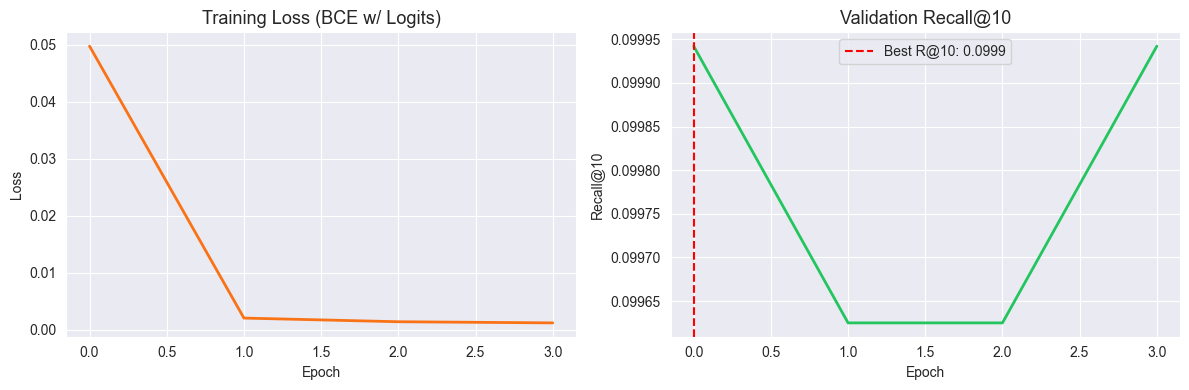

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, color='#f97316', linewidth=2)
ax1.set_title('Training Loss (BCE w/ Logits)', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(val_recalls, color='#22c55e', linewidth=2)
ax2.axvline(np.argmax(val_recalls), color='red', linestyle='--',
            label=f'Best R@10: {max(val_recalls):.4f}')
ax2.set_title('Validation Recall@10', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Recall@10')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/05_gru_training.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5.4 — Evaluate: Precision@10 and Recall@10

In [8]:
actuals_t, predicted_t = evaluate_top_k(gru_model, test_loader, DEVICE, k=10)

p10 = mean_precision_at_k(actuals_t, predicted_t, k=10)
r10 = mean_recall_at_k(actuals_t, predicted_t, k=10)
f10 = 2 * p10 * r10 / (p10 + r10 + 1e-9)

gru_metrics = {
    'precision':    p10,
    'precision_at_10': p10,
    'recall':       r10,
    'recall_at_10': r10,
    'f1':           f10,
    'f1_at_10':     f10,
}

print('GRU Sequential Recommender — Test Set (Top-K = 10)')
print('-' * 40)
print(f'  Precision@10 : {p10:.4f}')
print(f'  Recall@10    : {r10:.4f}')
print(f'  F1@10        : {f10:.4f}')

GRU Sequential Recommender — Test Set (Top-K = 10)
----------------------------------------
  Precision@10 : 0.0637
  Recall@10    : 0.0970
  F1@10        : 0.0769


## Step 5.5 — Full Four-Model Comparison Table

In [9]:
with open(f'{OUTPUTS_DIR}/model_results.json', 'r') as f:
    results = json.load(f)

results['gru'] = gru_metrics

with open(f'{OUTPUTS_DIR}/model_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print_metrics_table(results)
print('Note: GRU metrics are Precision@10 and Recall@10 (top-K recommendation).')
print('      RF and GBDT metrics are binary classification at threshold=0.5.')


Model                  Precision    Recall       F1           ROC-AUC     
--------------------------------------------------------------------------
random_forest          0.7683       0.0084       0.0167       0.7927      
gbdt                   0.3536       0.4573       0.3988       0.7867      
gru                    0.0637       0.0970       0.0769       Top-K only  

Note: GRU metrics are Precision@10 and Recall@10 (top-K recommendation).
      RF and GBDT metrics are binary classification at threshold=0.5.


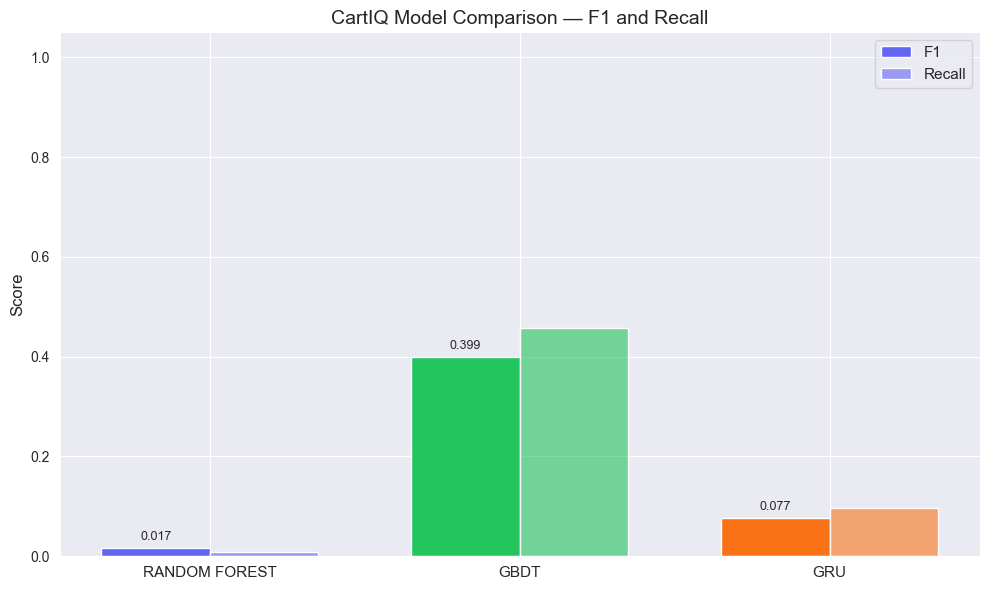

Phase 5 complete. Proceed to 06_error_analysis.ipynb


In [10]:
# Bar chart comparison
model_names = list(results.keys())
f1_values   = [results[m].get('f1', results[m].get('f1_at_10', 0)) for m in model_names]
recall_vals = [results[m].get('recall', results[m].get('recall_at_10', 0)) for m in model_names]
colors      = ['#6366f1', '#22c55e', '#f97316', '#ec4899']

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_f1  = ax.bar(x - width / 2, f1_values,   width, label='F1',   color=colors)
bars_r   = ax.bar(x + width / 2, recall_vals, width, label='Recall', color=[c + '99' for c in ['#6366f1', '#22c55e', '#f97316', '#ec4899']])

ax.set_xticks(x)
ax.set_xticklabels([m.upper().replace('_', ' ') for m in model_names], fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('CartIQ Model Comparison — F1 and Recall', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)

for bar in bars_f1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Phase 5 complete. Proceed to 06_error_analysis.ipynb')